# E2 · YOLOv8n + CLIP: recortar el animal antes de embeber

**Pregunta.** Si se elimina el fondo recortando al animal, ¿el embedding mide mejor la identidad que con la imagen completa (E1)?

| | |
|---|---|
| Pipeline | YOLOv8n (COCO, clases gato/perro) detecta al animal → recorte de la mejor caja con 10 % de margen (sin detección: imagen completa) → el mismo CLIP ViT-B/32 de E1 |
| Entrenamiento | ninguno (*zero-shot*); solo cambia el preprocesamiento respecto de E1 |
| Modelo | `pettrace-embedder` versión 2 (`clip-vit-b32-crop@v1`, alias `@candidate`); mismo encoder que E1 + `detector.onnx` |
| Dataset | `pettrace-reid@v3`, mismo protocolo que E1 |

Requiere haber ejecutado E1 (la comparación lee `reports/e1_v3`). Reproducir: `make notebook NB=notebooks/e2_yolo_crop_zero_shot.ipynb`.

In [1]:
import json, os

# Paths are relative to the repository root (nbconvert starts the kernel in notebooks/).
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR", "false")
os.environ.setdefault("TQDM_DISABLE", "1")
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
from collections import Counter

from IPython.display import Image, Markdown, display

from reid import data
from reid.evaluation import evaluate, load_model, log_run, report
from reid.figures import metrics_table, per_animal_table, save

print("código  :", os.environ.get("GIT_SHA", "?")[:7], "(sin cambios locales)" if os.environ.get("GIT_DIRTY") == "false" else "(¡cambios sin commit!)")
print("MLflow  :", os.environ.get("MLFLOW_TRACKING_URI"))

EXPERIMENT, DATASET, MODEL, REPORT = "E2", "v3", "models:/pettrace-embedder/2", "reports/e2_v3"
BASELINE = "reports/e1_v3/summary.json"

código  : c0712ff (sin cambios locales)
MLflow  : https://mlflow.chumpitaz.dev


## 1. Datos

In [2]:
ds = data.load(DATASET)
bucket = lambda x: "oscura" if x < 0.25 else "tenue" if x < 0.4 else "normal"
rows = ["| Especie | Animales | Fotos | Fotos por animal | Luz normal / tenue / oscura | Particiones |", "|---|---|---|---|---|---|"]
for sp in ("cat", "dog"):
    ph = [p for p in ds.photos if p.species == sp]
    per = Counter(p.animal for p in ph)
    light = Counter(bucket(p.light) for p in ph)
    splits = Counter(ds.animals[a]["split"] for a in per)
    rows.append(f"| {sp} | {len(per)} | {len(ph)} | {min(per.values())}–{max(per.values())} | "
                f"{light['normal']} / {light['tenue']} / {light['oscura']} | {dict(splits)} |")
display(Markdown(f"**{ds.name}** · commit `{ds.commit}` · huella `{ds.fingerprint}`\n\n" + "\n".join(rows)))
groups = Counter(r["lookalike_group"] for r in ds.animals.values() if r["lookalike_group"])
display(Markdown("Grupos de parecido (negativos difíciles): " + ", ".join(
    f"`{g}`: " + ", ".join(a for a, r in sorted(ds.animals.items()) if r["lookalike_group"] == g) for g in sorted(groups))))

**pettrace-reid@v3** · commit `354763693e9105eb953c559620037dd98995326b` · huella `1bd0c64aea5b64d9`

| Especie | Animales | Fotos | Fotos por animal | Luz normal / tenue / oscura | Particiones |
|---|---|---|---|---|---|
| cat | 7 | 61 | 5–10 | 46 / 10 / 5 | {'test': 7} |
| dog | 7 | 67 | 6–12 | 53 / 13 / 1 | {'test': 7} |

Grupos de parecido (negativos difíciles): `orange-white-1`: cat-04, cat-06, `shiba-1`: dog-05, dog-06, `tabby-1`: cat-01, cat-02, `white-curly-1`: dog-01, dog-02

## 2. Modelo

In [3]:
model = load_model(MODEL)
display(Markdown("\n".join([
    "| | |", "|---|---|",
    f"| URI | `{model.uri}` (versión {model.registry_version} del registro) |",
    f"| Pipeline | `{model.model_version}` |",
    *[f"| sha256 `{f}` | `{h}` |" for f, h in model.sha256.items()],
    f"| Golden set | huella `{model.golden_fingerprint}`, {'✓ reproduce los embeddings guardados' if model.golden_ok else '✗ NO coincide'} |",
])))
assert model.golden_ok, "the downloaded model does not reproduce its golden fingerprint"

det = model.pipeline.detector
display(Markdown(f"Detector: entrada {det.size} px, confianza mínima {det.conf}, clases COCO {det.classes} (gato, perro), margen {det.margin:.0%}."))

| | |
|---|---|
| URI | `models:/pettrace-embedder/2` (versión 2 del registro) |
| Pipeline | `clip-vit-b32-crop@v1` |
| sha256 `detector.onnx` | `da8f9b9ebea5157cdcefa7bea9fd782249ebdf119f917c07d64e5b41942b9c9d` |
| sha256 `encoder.onnx` | `4773e649274ca8774c4a63d45f0438fe598ee7ba67e65def97537aa0eca9a576` |
| Golden set | huella `5e40c7774bd7ad51`, ✓ reproduce los embeddings guardados |

Detector: entrada 640 px, confianza mínima 0.25, clases COCO [15, 16] (gato, perro), margen 10%.

## 3. Entrenamiento

No aplica (*zero-shot*). En su lugar se mide qué hace el detector sobre el dataset: en cuántas fotos encuentra al animal y cuánto de la imagen conserva.

In [4]:
from PIL import Image as PILImage, ImageOps

found, area, wrong_species = 0, [], 0
for p in ds.photos:
    img = ImageOps.exif_transpose(PILImage.open(p.path)).convert("RGB")
    box = det.box(img)
    if box is None:
        continue
    found += 1
    _, cls, (x1, y1, x2, y2) = box
    area.append(max(0, x2 - x1) * max(0, y2 - y1) / (img.width * img.height))
    wrong_species += {15: "cat", 16: "dog"}[cls] != p.species
display(Markdown(f"Animal detectado en **{found}/{len(ds.photos)}** fotos (el resto usa la imagen completa). "
                 f"El recorte conserva en mediana el **{sorted(area)[len(area)//2]:.0%}** de la imagen. "
                 f"Especie de la caja distinta a la etiqueta: {wrong_species} (no afecta: la búsqueda se filtra por la especie del reporte)."))

Animal detectado en **125/128** fotos (el resto usa la imagen completa). El recorte conserva en mediana el **37%** de la imagen. Especie de la caja distinta a la etiqueta: 6 (no afecta: la búsqueda se filtra por la especie del reporte).

## 4. Evaluación

In [5]:
ev = evaluate(ds, model.pipeline, zero_shot=True)
print(report(ev.result))

pettrace-reid@v3
group    queries gallery  Rank-1  Rank-5 Rank-10     mAP
global       128       7   70.3%   99.2%  100.0%   0.527
cat           61       7   65.6%   98.4%  100.0%   0.545
dog           67       7   74.6%  100.0%  100.0%   0.511
EER on all pairs (optimistic) 35.0% at threshold 0.812 → FAR 35.0%, FRR 35.0%


## 5. Resultados y comparación con E1

In [6]:
s2 = save(ev, model, REPORT)
s1 = json.load(open(BASELINE))
display(Markdown(metrics_table({"E1": s1, "E2": s2})))
display(Markdown(per_animal_table({"E1": s1, "E2": s2})))

| Métrica | E1 | E2 |
|---|---|---|
| Consultas / galería por especie | 128 / 7 animales | 128 / 7 animales |
| Rank-1 global (azar 14.3 %) | **73.4 %** | **70.3 %** |
| Rank-1 gatos / perros | 75.4 % / 71.6 % | 65.6 % / 74.6 % |
| Rank-5 global (azar 71.4 %) | 98.4 % | 99.2 % |
| mAP global | 0.509 | 0.527 |
| mAP gatos / perros | 0.569 / 0.453 | 0.545 / 0.511 |
| EER / umbral | 39.2 % / 0.794 | 35.0 % / 0.812 |
| Similitud mínima, mismo animal | 0.548 | 0.668 |
| Similitud máxima, distinto animal | 0.949 | 0.952 |

| Animal | E1 | E2 | E2: confundido con |
|---|---|---|---|
| cat-01 | 5/10 | 3/10 | cat-02 (6), cat-07 (1) |
| cat-02 | 7/10 | 6/10 | cat-01 (2), cat-04 (2) |
| cat-03 | 10/10 | 9/10 | cat-07 (1) |
| cat-04 | 6/10 | 4/10 | cat-02 (4), cat-01 (1), cat-06 (1) |
| cat-05 | 8/8 | 7/8 | cat-07 (1) |
| cat-06 | 8/8 | 8/8 | — |
| cat-07 | 2/5 | 3/5 | cat-01 (1), cat-03 (1) |
| dog-01 | 9/10 | 7/10 | dog-02 (2), dog-03 (1) |
| dog-02 | 9/12 | 8/12 | dog-01 (1), dog-03 (1), dog-04 (1), dog-06 (1) |
| dog-03 | 6/10 | 6/10 | dog-04 (2), dog-01 (1), dog-02 (1) |
| dog-04 | 5/10 | 7/10 | dog-01 (1), dog-02 (1), dog-03 (1) |
| dog-05 | 8/9 | 9/9 | — |
| dog-06 | 7/10 | 9/10 | dog-02 (1) |
| dog-07 | 4/6 | 4/6 | dog-01 (2) |

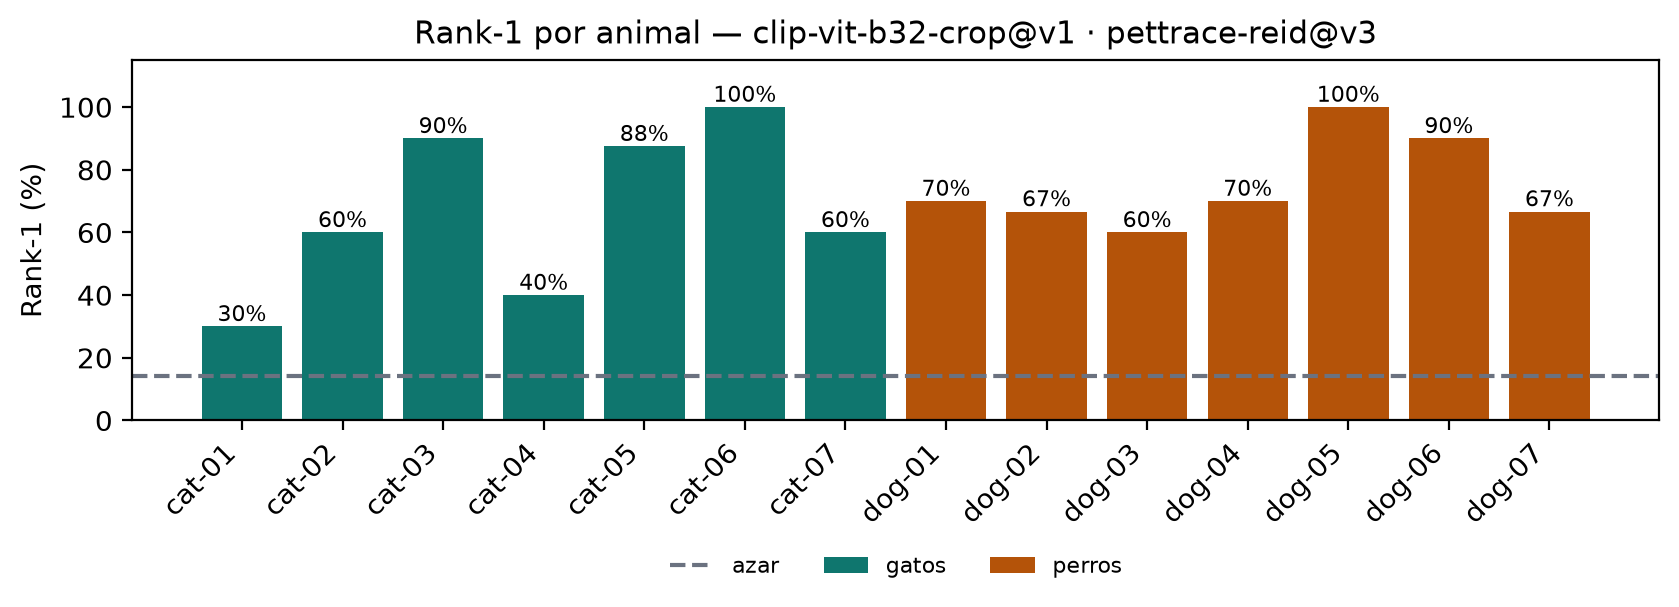

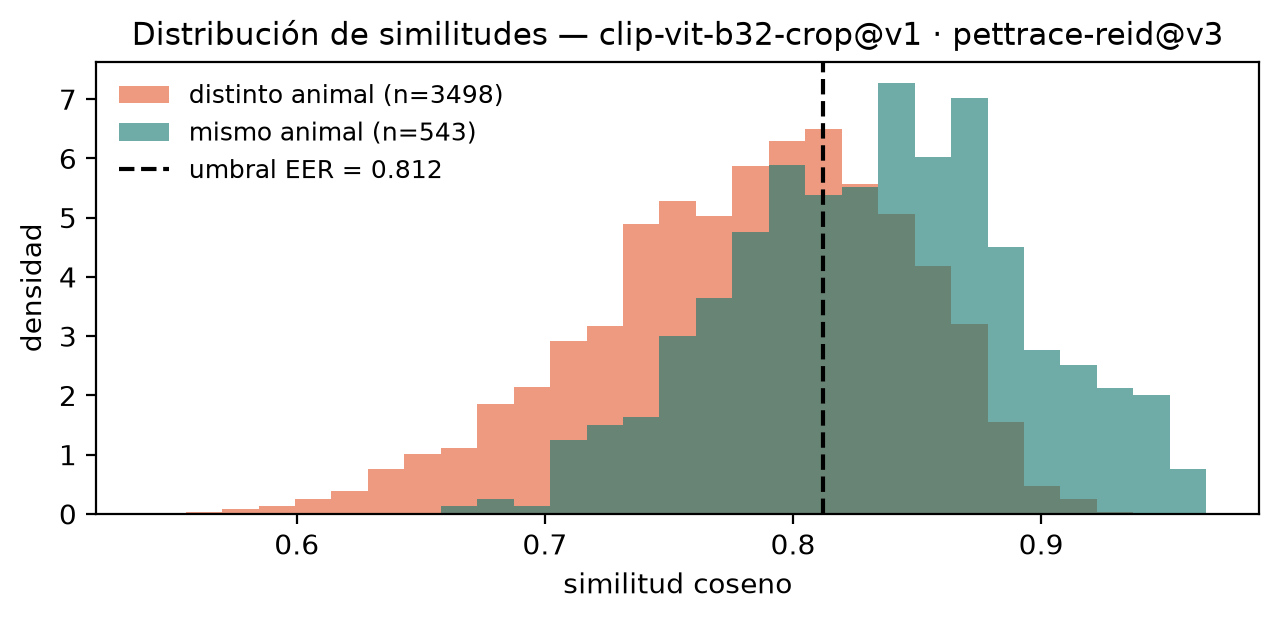

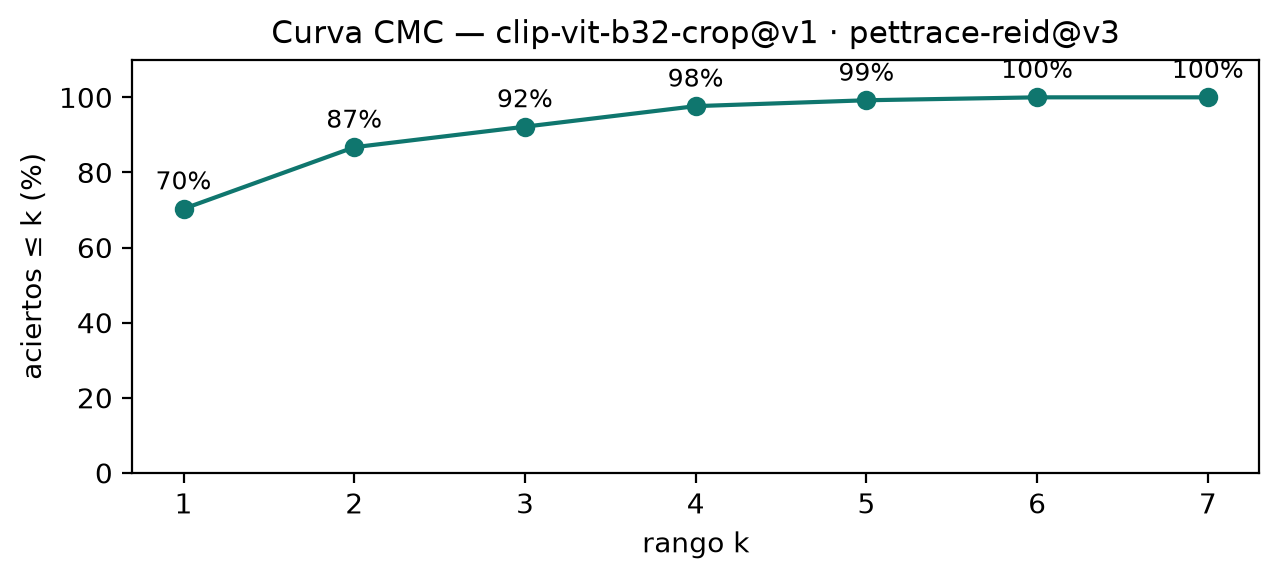

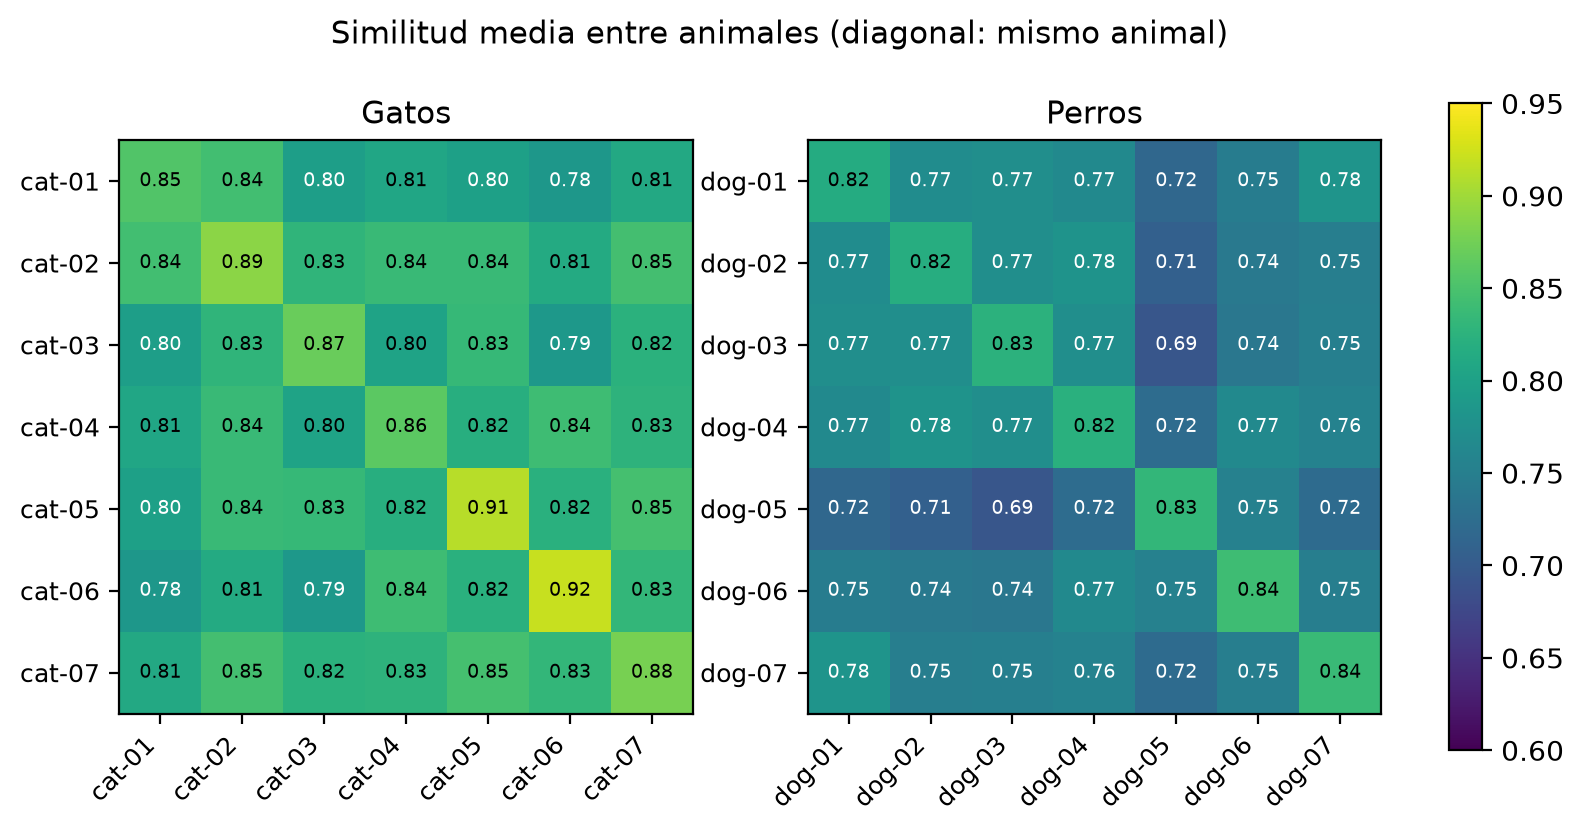

In [7]:
for name in ("rank1_por_animal", "distribucion_scores", "cmc", "matriz_similitud"):
    display(Image(os.path.join(REPORT, f"{name}.png"), width=760))

## 6. Registro en MLflow

In [8]:
run_id = log_run(ev, model, experiment=EXPERIMENT, artifacts=REPORT)
json.dump({"run_id": run_id, "experiment": EXPERIMENT, "dataset": ds.name, "dataset_commit": ds.commit,
           "model": MODEL, "git_sha": os.environ.get("GIT_SHA", "unknown")}, open(os.path.join(REPORT, "run.json"), "w"), indent=2)
display(Markdown(f"Ejecución MLflow: [`{run_id[:8]}`]({os.environ['MLFLOW_TRACKING_URI']}/#/experiments/"
                 f"{__import__('mlflow').get_experiment_by_name('pettrace-reid-eval').experiment_id}/runs/{run_id})"))

🏃 View run E2 · clip-vit-b32-crop@v1 on pettrace-reid@v3 at: https://mlflow.chumpitaz.dev/#/experiments/3/runs/f4dbc2a1189446edbb4b15f570d271de
🧪 View experiment at: https://mlflow.chumpitaz.dev/#/experiments/3


Ejecución MLflow: [`f4dbc2a1`](https://mlflow.chumpitaz.dev/#/experiments/3/runs/f4dbc2a1189446edbb4b15f570d271de)

## 7. Conclusiones

- **El recorte separa mejor las similitudes**: baja la EER y sube el mAP respecto de E1, y la similitud mínima entre fotos del mismo animal aumenta. En perros también mejora el Rank-1.
- **En gatos el Rank-1 baja**, y la caída se concentra en los grupos de parecido: `cat-01` se confunde con `cat-02` (mismo patrón atigrado) en 6 de sus 10 consultas. Sin el fondo, el modelo pierde pistas de entorno que ayudaban a E1 y el pelaje restante es casi idéntico.
- Por lo tanto, **parte del acierto de E1 venía del contexto de la foto**, que no existe cuando el avistamiento ocurre en la calle: E2 mide la identidad de forma más honesta y muestra que CLIP sin especializar no distingue gatos de pelaje parecido.
- Con 128 consultas la diferencia de Rank-1 entre E1 y E2 está dentro del ruido (intervalos de confianza pendientes). E2 queda como base para E3–E5: especializar el encoder con el dataset propio y re-ordenar con la descripción (p. ej. «le falta un ojo» para `cat-02`).